In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()
df['Churn'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,count
Churn,
No,5174
Yes,1869


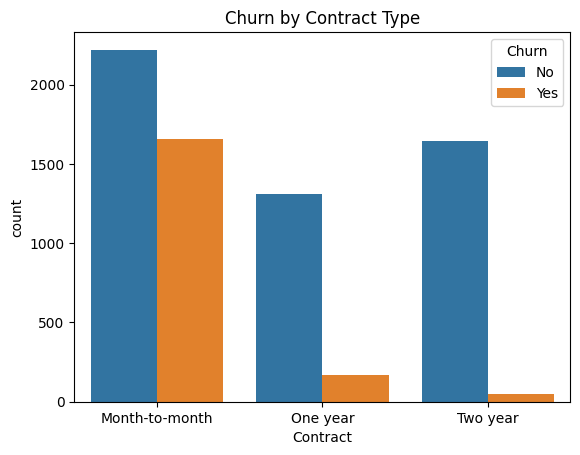

In [4]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Churn by Contract Type')
plt.show()

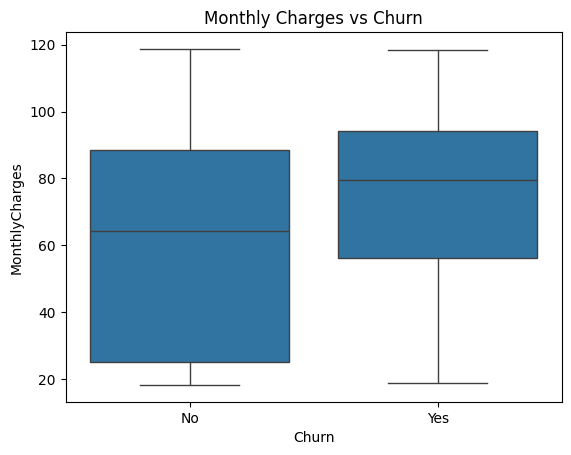

In [5]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title('Monthly Charges vs Churn')
plt.show()

In [6]:
df_encoded = pd.get_dummies(df.drop(columns=['customerID']), drop_first=True)

In [7]:
df_encoded['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df_encoded['TotalCharges'] = df_encoded['TotalCharges'].fillna(df_encoded['TotalCharges'].median())

In [8]:
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


Dataset imbalanced hai (apna actual percentage daal dena, jaise ~73% No churn, ~27% Yes churn). Isay abhi fully fix nahi kar rahe, lekin iska matlab hai accuracy akela bharosemand nahi hoga — is wajah se hum precision aur recall bhi dekhenge jab models evaluate karenge.

In [9]:
X = df_encoded.drop(columns=['Churn_Yes'])
y = df_encoded['Churn_Yes']

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

In [13]:
print('Decision Tree Accuracy:', accuracy_score(y_test, tree_model.predict(X_test)))
print('Logistic Regression Accuracy:', accuracy_score(y_test, log_model.predict(X_test)))

Decision Tree Accuracy: 0.7679205110007097
Logistic Regression Accuracy: 0.8218594748048261


In [14]:
importances = pd.Series(tree_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(importances.head(3))

tenure            0.175733
MonthlyCharges    0.106905
TotalCharges      0.104274
dtype: float64


Humne customer data analyze kar ke pata lagaya ke kaunse factors customers ko chhod kar jane (churn) par majboor karte hain. Sabse zyada asar tenure (customer kitne arse se company ke sath hai), Monthly Charges, aur Total Charges ka hai. Naye customers (kam tenure wale) aur zyada monthly bill dene wale customers ke chhodne ka khatra sabse zyada hai. Humne 2 models compare kiye — Logistic Regression ne 82% accuracy di jo Decision Tree ke 77% se behtar hai. Hum in high-risk customers ko waqt se pehle pehchan kar unhe khaas discounts ya loyalty offers de kar rok sakte hain, jisse company revenue bacha sakti hai.